In [1]:
import numpy as np
import matplotlib.pyplot as plt
from  scipy.stats import expon,gamma
from scipy.fft import fft,ifft

In [ ]:
# X1 ~ Exp(1),X2 ~ Exp(1),X3 ~ Exp(1), all independent
# Y=X1+X2+X3
# What is the distibution of Y
xvals= np.linspace(0,100,1000)
y1=expon.pdf(xvals,scale=1)
Y1 =fft(y1)

In [3]:
Y1[:10]

array([10.49834028-0.j        , 10.45913467-0.62407829j,
       10.34334268-1.23362026j, 10.15623058-1.81519585j,
        9.90592438-2.35741519j,  9.60257043-2.85156277j,
        9.2573913 -3.2918759j ,  8.88178459-3.6754865j ,
        8.48657536-4.00210066j,  8.08148067-4.27351646j])

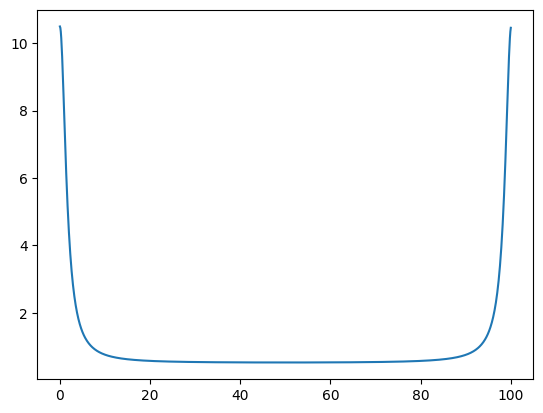

In [4]:
plt.plot(xvals,Y1.real );

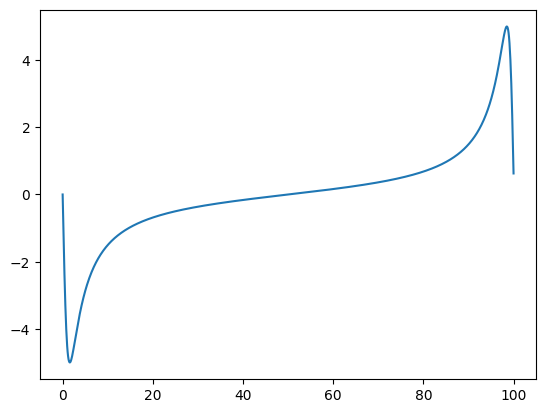

In [5]:
plt.plot(xvals,Y1.imag );

In [6]:
Y= Y1*Y1*Y1

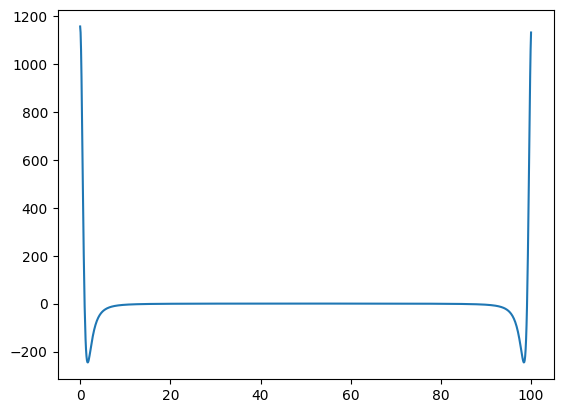

In [7]:
plt.plot(xvals,Y.real );

/home/section/sandman_venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/section/sandman_venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


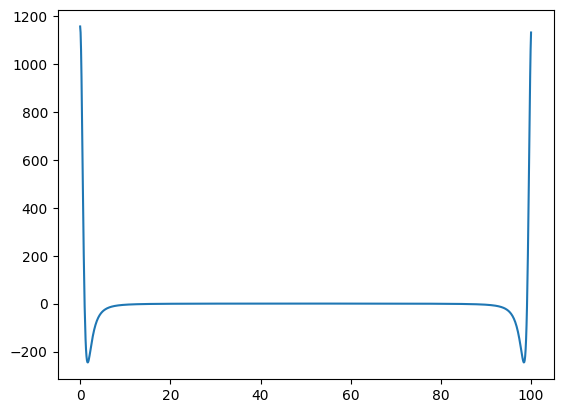

In [8]:
#Convert back to probability distribution
y=ifft(Y).real
plt.plot(xvals,Y);

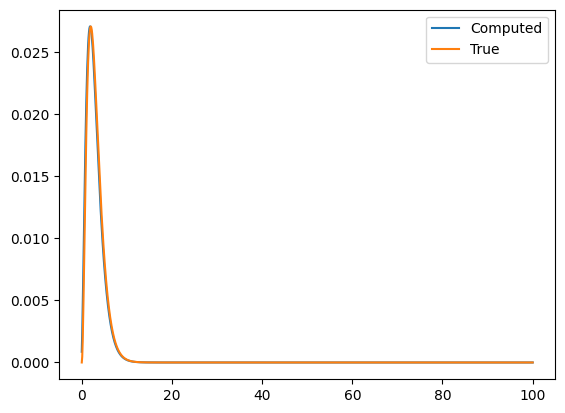

In [9]:
#Theorectical Answer

#CF of = 1/(1-it)
#CF of X1+X2+X3 = 1/(1-it)^3

#Same as CF  for Gamma with alpha =3 beta =1

z=gamma.pdf(xvals,a=3,scale =1)
plt.plot(xvals,y/y.sum(),label='Computed')
plt.plot(xvals,z/z.sum(),label='True')

plt.legend()

#note; we divide by sum because there are some scaling constants in actual fourier transform
